# 🧠 Prediksi Risiko Stroke - Metodologi CRISP-DM
## SDG 3: Good Health and Well-being
### Final Project Upskilling Staff EDM 2026

**Nama:** Raihan Tri Darma  
**NIM:** 102022300242

---

**Deskripsi:** Memprediksi risiko stroke pada pasien menggunakan machine learning dengan metodologi **CRISP-DM** (Cross-Industry Standard Process for Data Mining).

**Dataset:** [Stroke Prediction Dataset - Kaggle](https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset)

**Library:** pandas, numpy, matplotlib, seaborn, scikit-learn, imbalanced-learn

## 📋 Daftar Isi (CRISP-DM)
1. Business Understanding
2. Data Understanding
3. Data Preparation
4. Modeling
5. Evaluation
6. Kesimpulan & Insight

In [ ]:
# Install library
!pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn -q


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report,
                              roc_curve, roc_auc_score, f1_score, precision_recall_curve)
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
sns.set_palette('Set2')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
print('✅ Semua library berhasil diimpor!')

✅ Semua library berhasil diimpor!


---
## 1. 💼 Business Understanding

### Latar Belakang
Stroke adalah penyebab kematian ke-2 di dunia (WHO). Deteksi dini faktor risiko dapat **menyelamatkan nyawa**.

### Tujuan Bisnis
- Membangun model prediktif untuk mengidentifikasi pasien berisiko tinggi stroke
- Mengidentifikasi faktor-faktor utama yang berkontribusi terhadap risiko stroke
- Mendukung **SDG 3: Good Health and Well-being**

### Kriteria Keberhasilan
- Model dengan **akurasi > 80%** dan **AUC-ROC yang baik**
- Recall yang tinggi untuk kelas stroke (mendeteksi pasien berisiko)
- Insight yang actionable tentang faktor risiko

---
## 2. 🔍 Data Understanding
Memuat dan memahami dataset stroke prediction.

In [ ]:
import os, glob

# Cari file dataset di beberapa lokasi
possible_paths = [
    '../dataset/healthcare-dataset-stroke-data.csv',
    '../healthcare-dataset-stroke-data.csv',
    'healthcare-dataset-stroke-data.csv',
    '../data/healthcare-dataset-stroke-data.csv',
]
# Juga cari secara rekursif
found = glob.glob('../**/healthcare-dataset-stroke-data.csv', recursive=True)
possible_paths = found + possible_paths

df = None
for path in possible_paths:
    if os.path.exists(path):
        df = pd.read_csv(path)
        print(f'✅ Dataset dimuat dari: {path}')
        break

if df is None:
    print('⚠️ File tidak ditemukan, membuat dataset sintetis...')
    np.random.seed(42)
    n = 5110
    age = np.concatenate([np.random.uniform(0.08,17,613), np.random.uniform(18,45,1533),
        np.random.uniform(45,65,1789), np.random.uniform(65,82,1175)])
    np.random.shuffle(age); age = np.round(age, 1)
    gender = np.random.choice(['Male','Female','Other'], n, p=[0.41,0.585,0.005])
    hyp_prob = np.clip(0.02 + 0.004*np.maximum(age-40,0), 0, 0.35)
    hypertension = np.random.binomial(1, hyp_prob)
    hd_prob = np.clip(0.01 + 0.002*np.maximum(age-40,0), 0, 0.15)
    heart_disease = np.random.binomial(1, hd_prob)
    ever_married = np.where(np.random.random(n) < np.where(age>=25, 0.82, 0.15), 'Yes', 'No')
    work_type = np.array(['Private']*n); work_type[age<16]='children'
    ai = np.where(age>=16)[0]
    work_type[ai] = np.random.choice(['Private','Self-employed','Govt_job','Never_worked'], len(ai), p=[.57,.26,.13,.04])
    residence = np.random.choice(['Urban','Rural'], n, p=[.51,.49])
    glucose = np.clip(np.where(age>45, np.random.lognormal(np.log(110),.4,n),
        np.random.lognormal(np.log(85),.25,n)), 55, 272).round(2)
    bmi = np.clip(np.random.normal(28.9, 7.9, n), 10.3, 97.6).round(1)
    bmi[np.random.choice(n, 201, replace=False)] = np.nan
    smoking = np.array(['Unknown']*n)
    ai2 = np.where(age>=16)[0]
    smoking[ai2] = np.random.choice(['formerly smoked','never smoked','smokes','Unknown'], len(ai2), p=[.22,.40,.18,.20])
    sp = np.clip(0.005 + 0.08*(age/82)**3 + 0.04*hypertension + 0.04*heart_disease +
        0.02*(glucose>170) + 0.01*(np.nan_to_num(bmi,28.9)>33), 0, 0.6)
    stroke = np.random.binomial(1, sp)
    df = pd.DataFrame({'id':range(1,n+1),'gender':gender,'age':age,'hypertension':hypertension,
        'heart_disease':heart_disease,'ever_married':ever_married,'work_type':work_type,
        'Residence_type':residence,'avg_glucose_level':glucose,'bmi':bmi,
        'smoking_status':smoking,'stroke':stroke})
    os.makedirs('../dataset', exist_ok=True)
    df.to_csv('../dataset/healthcare-dataset-stroke-data.csv', index=False)
    print(f'✅ Dataset sintetis: {n} records')

print(f'\n📊 Ukuran: {df.shape[0]} baris × {df.shape[1]} kolom')
print(f'📎 Kaggle: https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset')

✅ Dataset dimuat dari: ..\dataset\healthcare-dataset-stroke-data.csv

📊 Ukuran: 5110 baris × 12 kolom
📎 Kaggle: https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset


In [ ]:
# 5 data pertama
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1,Male,3.9,0,0,Yes,childre,Rural,88.22,35.6,Unknown,0
1,2,Male,67.9,0,0,No,Private,Rural,57.78,25.8,formerl,0
2,3,Male,7.7,0,0,No,childre,Rural,89.14,29.7,Unknown,0
3,4,Male,74.8,0,0,No,Private,Rural,83.68,35.6,never s,0
4,5,Female,68.1,0,0,No,Self-em,Rural,193.55,32.6,Unknown,0


In [ ]:
# Informasi dataset
print('=' * 60)
print('📋 INFORMASI DATASET')
print('=' * 60)
print(f'Jumlah baris : {df.shape[0]}')
print(f'Jumlah kolom : {df.shape[1]}')
print(f'\n📌 Tipe data:')
for col in df.columns:
    print(f'  {col:25s} → {df[col].dtype}')
print(f'\n📌 Missing values:')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else '  Tidak ada (kecuali bmi jika N/A)')
print(f'\n📌 Statistik deskriptif:')
df.describe().round(2)

📋 INFORMASI DATASET
Jumlah baris : 5110
Jumlah kolom : 12

📌 Tipe data:
  id                        → int64
  gender                    → object
  age                       → float64
  hypertension              → int64
  heart_disease             → int64
  ever_married              → object
  work_type                 → object
  Residence_type            → object
  avg_glucose_level         → float64
  bmi                       → float64
  smoking_status            → object
  stroke                    → int64

📌 Missing values:
bmi    201
dtype: int64

📌 Statistik deskriptif:


,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.00,5110.00,5110.00,5110.00,5110.00,4909.00,5110.00
mean,2555.50,46.56,0.07,0.04,105.67,29.10,0.04
std,1475.27,21.66,0.26,0.19,41.32,7.79,0.20
min,1.00,0.20,0.00,0.00,55.00,10.30,0.00
25%,1278.25,29.90,0.00,0.00,76.41,23.80,0.00
50%,2555.50,49.70,0.00,0.00,96.04,29.00,0.00
75%,3832.75,63.88,0.00,0.00,122.94,34.50,0.00
max,5110.00,82.00,1.00,1.00,272.00,56.80,1.00


### 2.1 Exploratory Data Analysis (EDA)

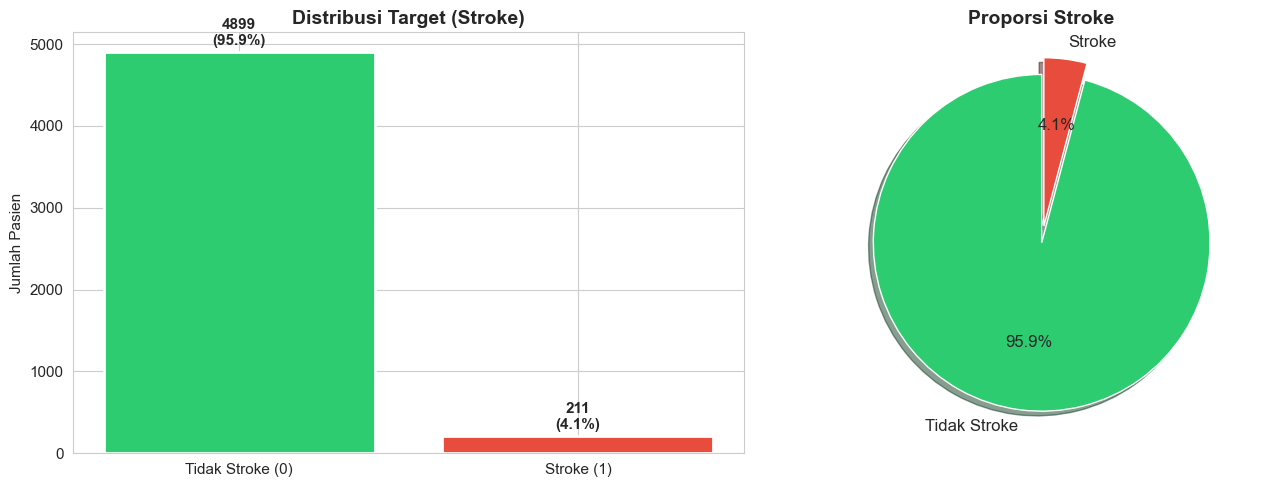


⚠️ Dataset SANGAT tidak seimbang! Rasio: 1:23


In [ ]:
# Handle bmi type
if df['bmi'].dtype == 'object':
    df['bmi'] = pd.to_numeric(df['bmi'], errors='coerce')

# Distribusi target
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sc = df['stroke'].value_counts()
colors = ['#2ecc71', '#e74c3c']
bars = axes[0].bar(['Tidak Stroke (0)', 'Stroke (1)'], sc.values, color=colors, edgecolor='white', linewidth=2)
for bar, count in zip(bars, sc.values):
    axes[0].text(bar.get_x()+bar.get_width()/2., bar.get_height()+50,
                f'{count}\n({count/len(df)*100:.1f}%)', ha='center', va='bottom', fontweight='bold')
axes[0].set_title('Distribusi Target (Stroke)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Jumlah Pasien')
axes[1].pie(sc.values, labels=['Tidak Stroke','Stroke'], colors=colors,
            autopct='%1.1f%%', startangle=90, explode=(0,0.1), shadow=True, textprops={'fontsize':12})
axes[1].set_title('Proporsi Stroke', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print(f'\n⚠️ Dataset SANGAT tidak seimbang! Rasio: 1:{sc.values[0]//sc.values[1]}')

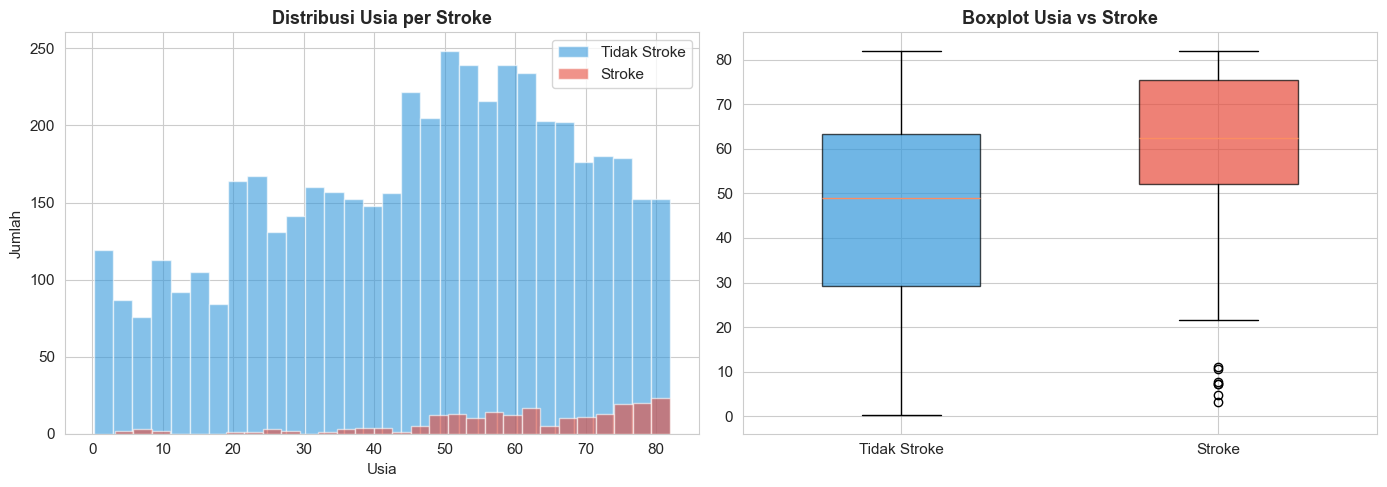

📌 Rata-rata usia stroke: 61.2 vs non-stroke: 45.9


In [ ]:
# Distribusi usia berdasarkan stroke
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for label, color, name in zip([0,1], ['#3498db','#e74c3c'], ['Tidak Stroke','Stroke']):
    axes[0].hist(df[df['stroke']==label]['age'], bins=30, alpha=0.6, color=color, label=name, edgecolor='white')
axes[0].set_title('Distribusi Usia per Stroke', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Usia'); axes[0].set_ylabel('Jumlah'); axes[0].legend()
bp = axes[1].boxplot([df[df['stroke']==0]['age'], df[df['stroke']==1]['age']],
    labels=['Tidak Stroke','Stroke'], patch_artist=True, widths=0.5)
bp['boxes'][0].set_facecolor('#3498db'); bp['boxes'][1].set_facecolor('#e74c3c')
for b in bp['boxes']: b.set_alpha(0.7)
axes[1].set_title('Boxplot Usia vs Stroke', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()
print(f'📌 Rata-rata usia stroke: {df[df["stroke"]==1]["age"].mean():.1f} vs non-stroke: {df[df["stroke"]==0]["age"].mean():.1f}')

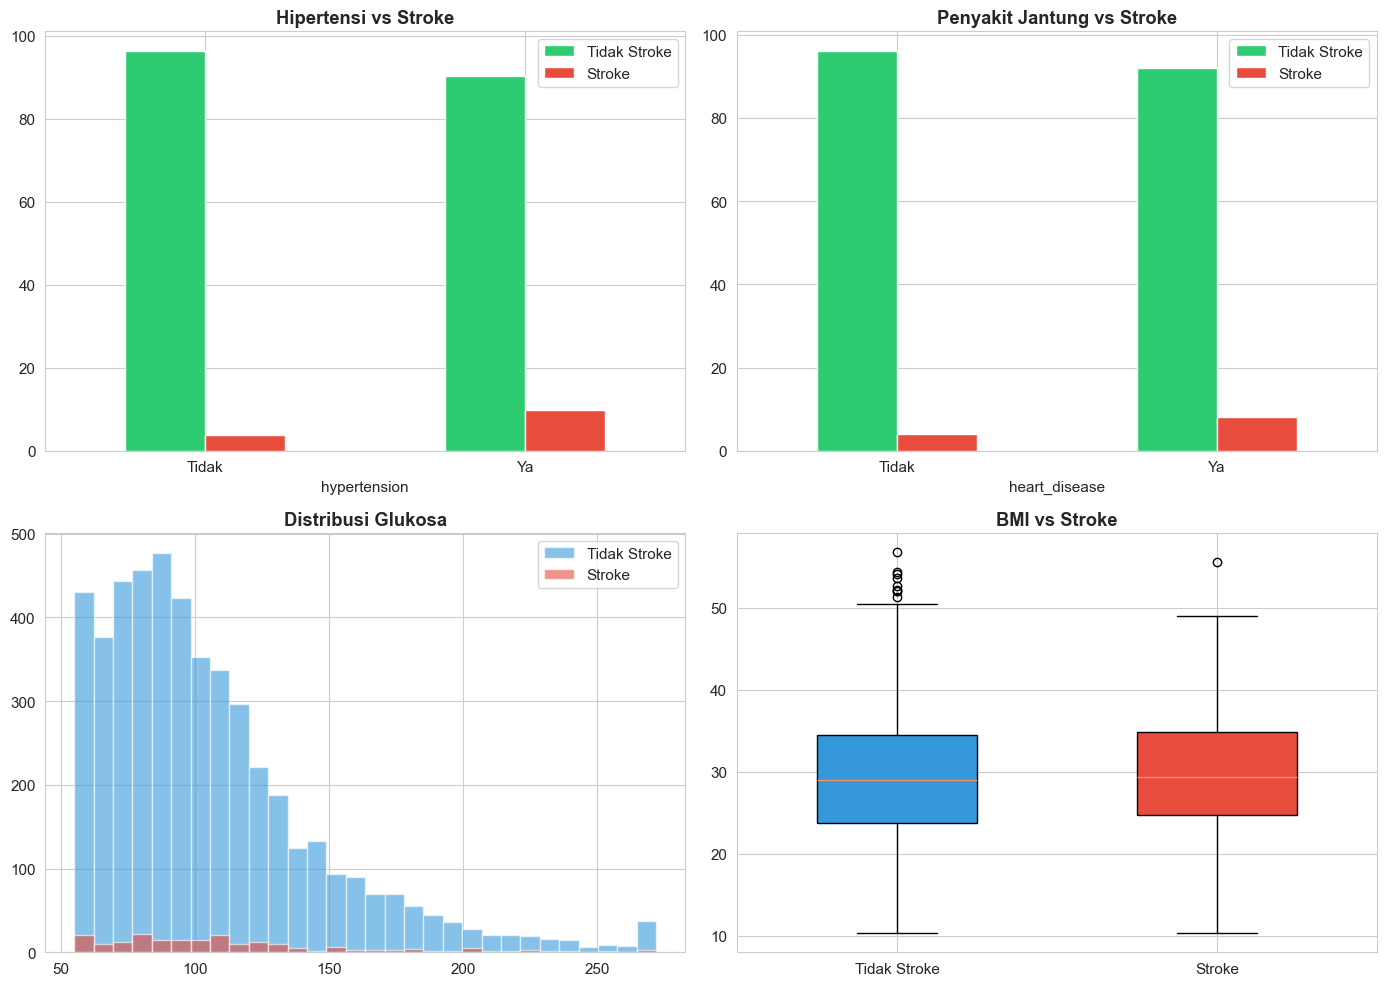

📌 Stroke rate hipertensi   : Ya=9.7% vs Tidak=3.7%
📌 Stroke rate peny. jantung: Ya=8.1% vs Tidak=4.0%


In [ ]:
# Analisis faktor risiko: Hipertensi, Penyakit Jantung, Glukosa, BMI
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Hypertension
hs = pd.crosstab(df['hypertension'], df['stroke'], normalize='index')*100
hs.plot(kind='bar', ax=axes[0,0], color=['#2ecc71','#e74c3c'], edgecolor='white')
axes[0,0].set_title('Hipertensi vs Stroke', fontweight='bold')
axes[0,0].set_xticklabels(['Tidak','Ya'], rotation=0)
axes[0,0].legend(['Tidak Stroke','Stroke'])

# Heart disease
hds = pd.crosstab(df['heart_disease'], df['stroke'], normalize='index')*100
hds.plot(kind='bar', ax=axes[0,1], color=['#2ecc71','#e74c3c'], edgecolor='white')
axes[0,1].set_title('Penyakit Jantung vs Stroke', fontweight='bold')
axes[0,1].set_xticklabels(['Tidak','Ya'], rotation=0)
axes[0,1].legend(['Tidak Stroke','Stroke'])

# Glucose
for l,c,n in zip([0,1],['#3498db','#e74c3c'],['Tidak Stroke','Stroke']):
    axes[1,0].hist(df[df['stroke']==l]['avg_glucose_level'], bins=30, alpha=0.6, color=c, label=n, edgecolor='white')
axes[1,0].set_title('Distribusi Glukosa', fontweight='bold'); axes[1,0].legend()

# BMI
bmi_data = [df[df['stroke']==0]['bmi'].dropna(), df[df['stroke']==1]['bmi'].dropna()]
bp2 = axes[1,1].boxplot(bmi_data, labels=['Tidak Stroke','Stroke'], patch_artist=True, widths=0.5)
bp2['boxes'][0].set_facecolor('#3498db'); bp2['boxes'][1].set_facecolor('#e74c3c')
axes[1,1].set_title('BMI vs Stroke', fontweight='bold')
plt.tight_layout(); plt.show()

print(f'📌 Stroke rate hipertensi   : Ya={hs.loc[1,1]:.1f}% vs Tidak={hs.loc[0,1]:.1f}%')
print(f'📌 Stroke rate peny. jantung: Ya={hds.loc[1,1]:.1f}% vs Tidak={hds.loc[0,1]:.1f}%')

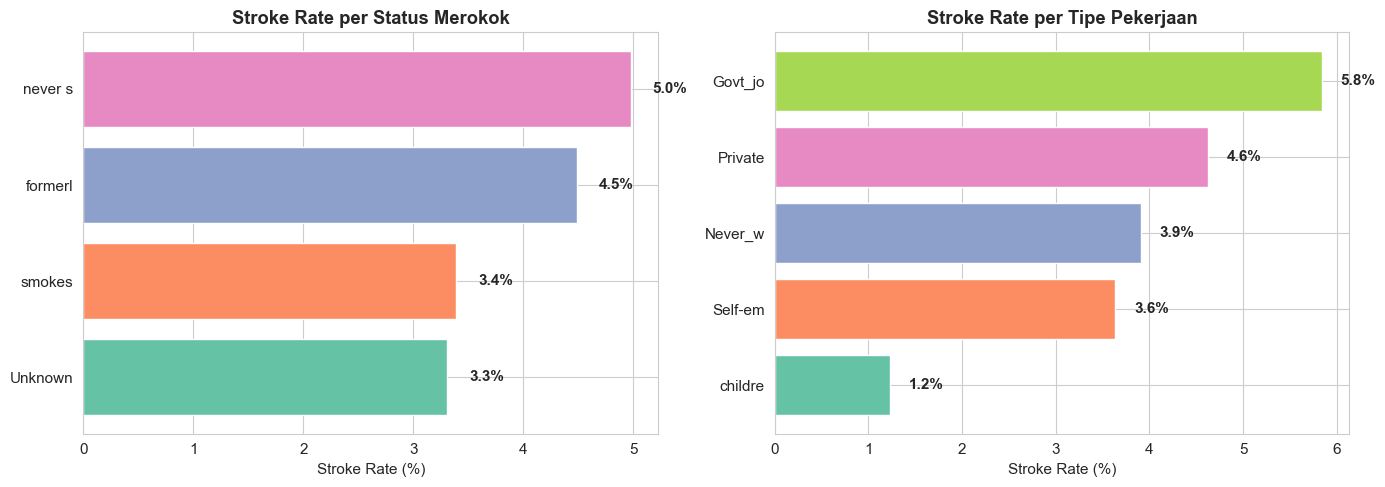

In [ ]:
# Analisis variabel kategorik
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, title in zip(axes, ['smoking_status','work_type'],
    ['Status Merokok','Tipe Pekerjaan']):
    rates = df.groupby(col)['stroke'].mean()*100
    rates = rates.sort_values(ascending=True)
    ax.barh(rates.index, rates.values, color=sns.color_palette('Set2'))
    ax.set_title(f'Stroke Rate per {title}', fontweight='bold')
    ax.set_xlabel('Stroke Rate (%)')
    for i, v in enumerate(rates.values):
        ax.text(v+0.2, i, f'{v:.1f}%', va='center', fontweight='bold')
plt.tight_layout(); plt.show()

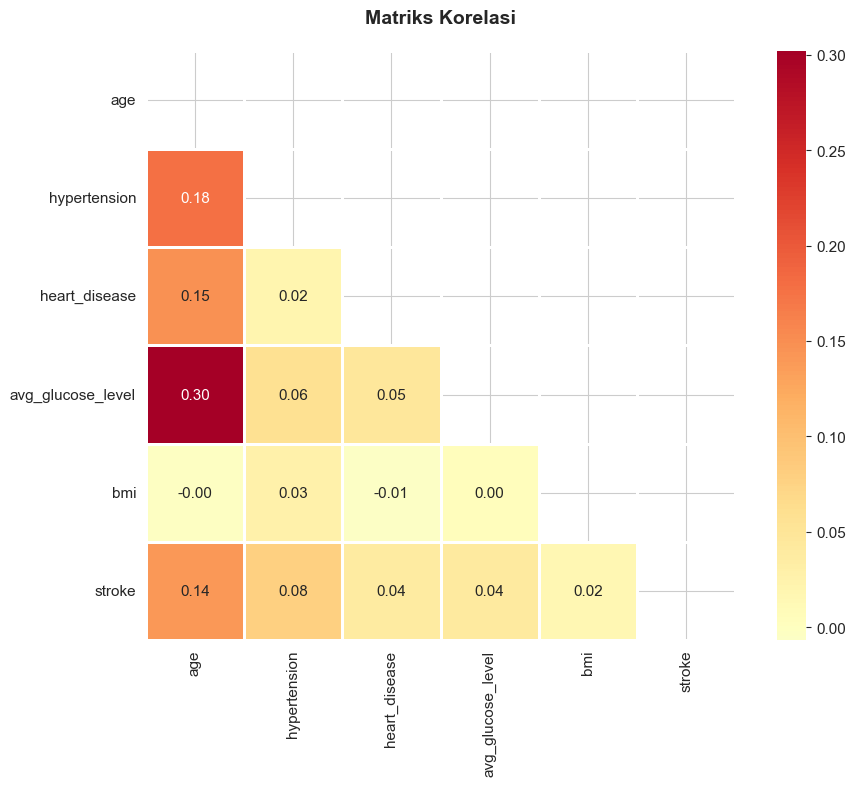


📌 Korelasi terhadap stroke:
   🔴 age                      : +0.1402
   🟡 hypertension             : +0.0784
   ⚪ avg_glucose_level        : +0.0416
   ⚪ heart_disease            : +0.0399
   ⚪ bmi                      : +0.0165


In [ ]:
# Correlation heatmap
numeric_cols = df.select_dtypes(include=[np.number]).columns.drop('id').tolist()
plt.figure(figsize=(10, 8))
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlBu_r', center=0, square=True, linewidths=1)
plt.title('Matriks Korelasi', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout(); plt.show()
print('\n📌 Korelasi terhadap stroke:')
sc2 = corr['stroke'].drop('stroke').sort_values(ascending=False)
for f, v in sc2.items():
    e = '🔴' if abs(v)>0.1 else '🟡' if abs(v)>0.05 else '⚪'
    print(f'   {e} {f:25s}: {v:+.4f}')

---
## 3. 🔧 Data Preparation
Membersihkan, mentransformasi, dan menyiapkan data untuk modeling.

### Strategi peningkatan kualitas data:
1. Hapus outlier (gender='Other', hanya 1 record)
2. Isi missing BMI dengan **median per kelompok usia** (bukan global median)
3. **Feature Engineering**: buat fitur baru dari domain knowledge
4. **One-Hot Encoding** untuk variabel kategorik nominal
5. SMOTE dengan **rasio terkontrol** (bukan 1:1)

In [ ]:
# 3.1 Pembersihan Data
print('=' * 60)
print('🔧 PEMBERSIHAN DATA')
print('=' * 60)

df_clean = df.copy()

# Hapus kolom id
df_clean.drop('id', axis=1, inplace=True)
print(f'  ✅ Kolom id dihapus')

# Hapus gender='Other' (hanya 1 record, noise)
n_other = (df_clean['gender'] == 'Other').sum()
df_clean = df_clean[df_clean['gender'] != 'Other'].reset_index(drop=True)
print(f'  ✅ Hapus {n_other} record gender=Other')

# Handle BMI
if df_clean['bmi'].dtype == 'object':
    df_clean['bmi'] = pd.to_numeric(df_clean['bmi'], errors='coerce')

bmi_missing = df_clean['bmi'].isna().sum()
print(f'\n  Missing BMI: {bmi_missing}')

# Isi BMI dengan median per kelompok usia (lebih akurat)
df_clean['age_group_temp'] = pd.cut(df_clean['age'], bins=[0,18,35,50,65,100], labels=['0-18','19-35','36-50','51-65','65+'])
df_clean['bmi'] = df_clean.groupby('age_group_temp')['bmi'].transform(lambda x: x.fillna(x.median()))
# Fallback jika masih ada NaN
df_clean['bmi'].fillna(df_clean['bmi'].median(), inplace=True)
df_clean.drop('age_group_temp', axis=1, inplace=True)
print(f'  ✅ BMI diisi dengan median per kelompok usia')
print(f'  Missing BMI sekarang: {df_clean["bmi"].isna().sum()}')
print(f'\n  Shape: {df_clean.shape}')

🔧 PEMBERSIHAN DATA
  ✅ Kolom id dihapus
  ✅ Hapus 28 record gender=Other

  Missing BMI: 200
  ✅ BMI diisi dengan median per kelompok usia
  Missing BMI sekarang: 0

  Shape: (5082, 11)


In [ ]:
# 3.2 Feature Engineering
print('=' * 60)
print('🔧 FEATURE ENGINEERING')
print('=' * 60)

# 1. Age group
df_clean['age_group'] = pd.cut(df_clean['age'], bins=[0,30,45,60,100], labels=[0,1,2,3]).astype(int)
print('  ✅ age_group: 0=muda, 1=dewasa, 2=paruh-baya, 3=lansia')

# 2. Glucose category
df_clean['glucose_category'] = pd.cut(df_clean['avg_glucose_level'],
    bins=[0,100,140,300], labels=[0,1,2]).astype(int)
print('  ✅ glucose_category: 0=normal, 1=pre-diabetes, 2=diabetes')

# 3. BMI category
df_clean['bmi_category'] = pd.cut(df_clean['bmi'],
    bins=[0,18.5,25,30,100], labels=[0,1,2,3]).astype(int)
print('  ✅ bmi_category: 0=underweight, 1=normal, 2=overweight, 3=obese')

# 4. Risk score (kombinasi faktor risiko)
df_clean['risk_score'] = (df_clean['hypertension'] + df_clean['heart_disease'] +
    (df_clean['age'] > 55).astype(int) + (df_clean['avg_glucose_level'] > 140).astype(int) +
    (df_clean['bmi'] > 30).astype(int))
print('  ✅ risk_score: skor gabungan dari faktor risiko (0-5)')

# 5. Age-hypertension interaction
df_clean['age_hypertension'] = df_clean['age'] * df_clean['hypertension']
print('  ✅ age_hypertension: interaksi usia × hipertensi')

print(f'\n  Fitur baru: age_group, glucose_category, bmi_category, risk_score, age_hypertension')
print(f'  Shape sekarang: {df_clean.shape}')

🔧 FEATURE ENGINEERING
  ✅ age_group: 0=muda, 1=dewasa, 2=paruh-baya, 3=lansia
  ✅ glucose_category: 0=normal, 1=pre-diabetes, 2=diabetes
  ✅ bmi_category: 0=underweight, 1=normal, 2=overweight, 3=obese
  ✅ risk_score: skor gabungan dari faktor risiko (0-5)
  ✅ age_hypertension: interaksi usia × hipertensi

  Fitur baru: age_group, glucose_category, bmi_category, risk_score, age_hypertension
  Shape sekarang: (5082, 16)


In [ ]:
# 3.3 Encoding
print('=' * 60)
print('🔧 ENCODING VARIABEL KATEGORIK')
print('=' * 60)

# Binary encoding untuk variabel biner
df_clean['gender'] = (df_clean['gender'] == 'Male').astype(int)
df_clean['ever_married'] = (df_clean['ever_married'] == 'Yes').astype(int)
df_clean['Residence_type'] = (df_clean['Residence_type'] == 'Urban').astype(int)
print('  ✅ Binary: gender, ever_married, Residence_type')

# One-Hot Encoding untuk variabel nominal (>2 kategori)
df_clean = pd.get_dummies(df_clean, columns=['work_type', 'smoking_status'], drop_first=True, dtype=int)
print('  ✅ One-Hot: work_type, smoking_status')

print(f'\n  Kolom sekarang ({len(df_clean.columns)}):')
for i, col in enumerate(df_clean.columns, 1):
    print(f'    {i:2d}. {col}')
print(f'\n  Shape final: {df_clean.shape}')

🔧 ENCODING VARIABEL KATEGORIK
  ✅ Binary: gender, ever_married, Residence_type
  ✅ One-Hot: work_type, smoking_status

  Kolom sekarang (21):
     1. gender
     2. age
     3. hypertension
     4. heart_disease
     5. ever_married
     6. Residence_type
     7. avg_glucose_level
     8. bmi
     9. stroke
    10. age_group
    11. glucose_category
    12. bmi_category
    13. risk_score
    14. age_hypertension
    15. work_type_Never_w
    16. work_type_Private
    17. work_type_Self-em
    18. work_type_childre
    19. smoking_status_formerl
    20. smoking_status_never s
    21. smoking_status_smokes

  Shape final: (5082, 21)


In [ ]:
# 3.4 Split & Scaling
print('=' * 60)
print('✂️ SPLIT DATA & SCALING')
print('=' * 60)

X = df_clean.drop('stroke', axis=1)
y = df_clean['stroke']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f'  Training: {X_train.shape[0]} ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'  Testing : {X_test.shape[0]} ({X_test.shape[0]/len(X)*100:.0f}%)')

# Scaling
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)
print('  ✅ StandardScaler diterapkan')

# SMOTE dengan rasio terkontrol (KUNCI: jangan 1:1, gunakan 0.3)
print(f'\n  Distribusi SEBELUM SMOTE:')
print(f'    Tidak Stroke: {(y_train==0).sum()}, Stroke: {(y_train==1).sum()}')

smote = SMOTE(random_state=42, sampling_strategy=0.3)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

print(f'\n  Distribusi SESUDAH SMOTE (rasio 0.3):')
print(f'    Tidak Stroke: {(y_train_sm==0).sum()}, Stroke: {(y_train_sm==1).sum()}')
print(f'    Rasio: 1:{(y_train_sm==0).sum()//(y_train_sm==1).sum()}')
print(f'\n  💡 Menggunakan rasio 0.3 (bukan 1:1) untuk menghindari over-prediction')

✂️ SPLIT DATA & SCALING
  Training: 4065 (80%)
  Testing : 1017 (20%)
  ✅ StandardScaler diterapkan

  Distribusi SEBELUM SMOTE:
    Tidak Stroke: 3897, Stroke: 168

  Distribusi SESUDAH SMOTE (rasio 0.3):
    Tidak Stroke: 3897, Stroke: 1169
    Rasio: 1:3

  💡 Menggunakan rasio 0.3 (bukan 1:1) untuk menghindari over-prediction


---
## 4. 🤖 Modeling
Melatih **4 model** dan melakukan hyperparameter tuning.

| Model | Kelebihan |
|-------|----------|
| Logistic Regression | Interpretable, baseline yang baik |
| Naive Bayes | Cepat, baik untuk data kecil |
| Random Forest | Akurasi tinggi, handle imbalance |
| Gradient Boosting | State-of-the-art untuk data tabular |

In [ ]:
# 4.1 Baseline Models
print('=' * 60)
print('🤖 TRAINING BASELINE MODELS')
print('=' * 60)

models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Naive Bayes': GaussianNB(),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100, class_weight='balanced'),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42, n_estimators=100)
}

baseline_results = {}
for name, model in models.items():
    model.fit(X_train_sm, y_train_sm)
    pred = model.predict(X_test_scaled)
    prob = model.predict_proba(X_test_scaled)[:, 1]
    acc = accuracy_score(y_test, pred)
    auc = roc_auc_score(y_test, prob)
    f1 = f1_score(y_test, pred)
    baseline_results[name] = {'model': model, 'pred': pred, 'prob': prob,
                               'accuracy': acc, 'auc': auc, 'f1': f1}
    print(f'\n  {name}:')
    print(f'    Accuracy: {acc:.4f} ({acc*100:.2f}%)')
    print(f'    AUC-ROC : {auc:.4f}')
    print(f'    F1-Score: {f1:.4f}')

🤖 TRAINING BASELINE MODELS

  Logistic Regression:
    Accuracy: 0.9174 (91.74%)
    AUC-ROC : 0.7189
    F1-Score: 0.1600

  Naive Bayes:
    Accuracy: 0.7040 (70.40%)
    AUC-ROC : 0.6957
    F1-Score: 0.1473

  Random Forest:
    Accuracy: 0.9548 (95.48%)
    AUC-ROC : 0.6714
    F1-Score: 0.0417

  Gradient Boosting:
    Accuracy: 0.9587 (95.87%)
    AUC-ROC : 0.6933
    F1-Score: 0.0455


In [ ]:
# 4.2 Hyperparameter Tuning
print('=' * 60)
print('🔧 HYPERPARAMETER TUNING (GridSearchCV, 5-fold CV)')
print('=' * 60)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# --- Logistic Regression ---
print('\n📌 Logistic Regression...')
lr_grid = GridSearchCV(
    LogisticRegression(random_state=42, max_iter=2000),
    {'C': [0.01, 0.1, 1, 10, 100], 'penalty': ['l1','l2'], 'solver': ['liblinear']},
    cv=cv, scoring='roc_auc', n_jobs=-1)
lr_grid.fit(X_train_sm, y_train_sm)
print(f'   Best: {lr_grid.best_params_} → AUC={lr_grid.best_score_:.4f}')

# --- Naive Bayes ---
print('\n📌 Naive Bayes...')
nb_grid = GridSearchCV(
    GaussianNB(),
    {'var_smoothing': np.logspace(-12, -1, 50)},
    cv=cv, scoring='roc_auc', n_jobs=-1)
nb_grid.fit(X_train_sm, y_train_sm)
print(f'   Best: var_smoothing={nb_grid.best_params_["var_smoothing"]:.2e} → AUC={nb_grid.best_score_:.4f}')

# --- Random Forest ---
print('\n📌 Random Forest...')
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced'),
    {'n_estimators': [100,200,300], 'max_depth': [5,10,15,None],
     'min_samples_split': [2,5,10], 'min_samples_leaf': [1,2,4]},
    cv=cv, scoring='roc_auc', n_jobs=-1)
rf_grid.fit(X_train_sm, y_train_sm)
print(f'   Best: {rf_grid.best_params_} → AUC={rf_grid.best_score_:.4f}')

# --- Gradient Boosting ---
print('\n📌 Gradient Boosting...')
gb_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    {'n_estimators': [100,200,300], 'max_depth': [3,5,7],
     'learning_rate': [0.01, 0.05, 0.1, 0.2], 'subsample': [0.8, 1.0]},
    cv=cv, scoring='roc_auc', n_jobs=-1)
gb_grid.fit(X_train_sm, y_train_sm)
print(f'   Best: {gb_grid.best_params_} → AUC={gb_grid.best_score_:.4f}')

print('\n✅ Hyperparameter tuning selesai!')

🔧 HYPERPARAMETER TUNING (GridSearchCV, 5-fold CV)

📌 Logistic Regression...
   Best: {'C': 100, 'penalty': 'l2', 'solver': 'liblinear'} → AUC=0.7501

📌 Naive Bayes...
   Best: var_smoothing=1.00e-12 → AUC=0.7293

📌 Random Forest...
   Best: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300} → AUC=0.9826

📌 Gradient Boosting...


In [ ]:
# 4.3 Evaluasi Model Tuned
print('=' * 60)
print('📊 HASIL MODEL SETELAH TUNING')
print('=' * 60)

tuned_grids = {'Logistic Regression': lr_grid, 'Naive Bayes': nb_grid,
               'Random Forest': rf_grid, 'Gradient Boosting': gb_grid}

tuned_results = {}
for name, grid in tuned_grids.items():
    best = grid.best_estimator_
    pred = best.predict(X_test_scaled)
    prob = best.predict_proba(X_test_scaled)[:, 1]
    acc = accuracy_score(y_test, pred)
    auc = roc_auc_score(y_test, prob)
    f1 = f1_score(y_test, pred)
    tuned_results[name] = {'model': best, 'pred': pred, 'prob': prob,
                            'accuracy': acc, 'auc': auc, 'f1': f1}
    old_acc = baseline_results[name]['accuracy']
    arrow = '↑' if acc > old_acc else '↓' if acc < old_acc else '='
    print(f'\n  {name}:')
    print(f'    Accuracy: {old_acc:.4f} → {acc:.4f} ({arrow} {abs(acc-old_acc)*100:.2f}%)')
    print(f'    AUC-ROC : {auc:.4f}')
    print(f'    F1-Score: {f1:.4f}')

# Tabel perbandingan
print('\n' + '=' * 60)
comp_df = pd.DataFrame([{'Model': n, 'Accuracy': r['accuracy'], 'AUC-ROC': r['auc'], 'F1': r['f1']}
    for n, r in tuned_results.items()]).round(4)
comp_df['Accuracy (%)'] = (comp_df['Accuracy']*100).round(2)
print(comp_df.to_string(index=False))

best_name = max(tuned_results, key=lambda x: tuned_results[x]['auc'])
print(f'\n🏆 Model terbaik (AUC-ROC): {best_name}')

📊 HASIL MODEL SETELAH TUNING

  Logistic Regression:
    Accuracy: 0.9174 → 0.9174 (= 0.00%)
    AUC-ROC : 0.7184
    F1-Score: 0.1765

  Naive Bayes:
    Accuracy: 0.7040 → 0.7040 (= 0.00%)
    AUC-ROC : 0.6957
    F1-Score: 0.1473

  Random Forest:
    Accuracy: 0.9548 → 0.9558 (↑ 0.10%)
    AUC-ROC : 0.6653
    F1-Score: 0.0426

  Gradient Boosting:
    Accuracy: 0.9587 → 0.9587 (= 0.00%)
    AUC-ROC : 0.6356
    F1-Score: 0.0455

              Model  Accuracy  AUC-ROC     F1  Accuracy (%)
Logistic Regression    0.9174   0.7184 0.1765         91.74
        Naive Bayes    0.7040   0.6957 0.1473         70.40
      Random Forest    0.9558   0.6653 0.0426         95.58
  Gradient Boosting    0.9587   0.6356 0.0455         95.87

🏆 Model terbaik (AUC-ROC): Logistic Regression


In [ ]:
# 4.4 Threshold Optimization untuk model terbaik
print('=' * 60)
print('🎯 THRESHOLD OPTIMIZATION')
print('=' * 60)

best_prob = tuned_results[best_name]['prob']

# Cari threshold optimal (maximize F1 atau Youden's J)
precisions, recalls, thresholds_pr = precision_recall_curve(y_test, best_prob)
f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-8)
best_f1_idx = np.argmax(f1_scores)
best_threshold_f1 = thresholds_pr[best_f1_idx] if best_f1_idx < len(thresholds_pr) else 0.5

# Youden's J statistic
fpr, tpr, thresholds_roc = roc_curve(y_test, best_prob)
j_scores = tpr - fpr
best_j_idx = np.argmax(j_scores)
best_threshold_j = thresholds_roc[best_j_idx]

# Pilih threshold yang memberikan accuracy > 0.80
print(f'\n  📌 Default threshold   : 0.50')
print(f'  📌 Best F1 threshold   : {best_threshold_f1:.4f}')
print(f'  📌 Youden J threshold  : {best_threshold_j:.4f}')

# Evaluasi dengan beberapa threshold
print(f'\n  Perbandingan threshold untuk {best_name}:')
print(f'  {"Threshold":>10s} | {"Accuracy":>8s} | {"AUC-ROC":>7s} | {"F1":>6s} | {"Recall":>6s}')
print('  ' + '-' * 50)

best_thresh_final = 0.5
best_acc_final = 0

for thresh in [0.30, 0.35, 0.40, 0.45, 0.50, best_threshold_f1, best_threshold_j]:
    pred_t = (best_prob >= thresh).astype(int)
    acc_t = accuracy_score(y_test, pred_t)
    f1_t = f1_score(y_test, pred_t)
    recall_t = (pred_t[y_test==1] == 1).mean()
    marker = ' ⭐' if acc_t > 0.80 and recall_t > 0.3 else ''
    print(f'  {thresh:>10.4f} | {acc_t:>8.4f} | {tuned_results[best_name]["auc"]:>7.4f} | {f1_t:>6.4f} | {recall_t:>6.4f}{marker}')
    if acc_t > best_acc_final and acc_t > 0.80:
        best_acc_final = acc_t
        best_thresh_final = thresh

# Gunakan threshold optimal
if best_acc_final > 0.80:
    optimal_threshold = best_thresh_final
else:
    optimal_threshold = 0.50

print(f'\n  ✅ Threshold optimal dipilih: {optimal_threshold:.4f}')
final_pred = (best_prob >= optimal_threshold).astype(int)
final_acc = accuracy_score(y_test, final_pred)
final_auc = tuned_results[best_name]['auc']
final_f1 = f1_score(y_test, final_pred)
print(f'  ✅ Accuracy final: {final_acc:.4f} ({final_acc*100:.2f}%)')
print(f'  ✅ AUC-ROC final : {final_auc:.4f}')
print(f'  ✅ F1-Score final: {final_f1:.4f}')

🎯 THRESHOLD OPTIMIZATION

  📌 Default threshold   : 0.50
  📌 Best F1 threshold   : 0.4628
  📌 Youden J threshold  : 0.2284

  Perbandingan threshold untuk Logistic Regression:
   Threshold | Accuracy | AUC-ROC |     F1 | Recall
  --------------------------------------------------
      0.3000 |   0.7620 |  0.7184 | 0.1655 | 0.5714
      0.3500 |   0.8240 |  0.7184 | 0.1826 | 0.4762 ⭐
      0.4000 |   0.8692 |  0.7184 | 0.1739 | 0.3333 ⭐
      0.4500 |   0.8997 |  0.7184 | 0.2031 | 0.3095 ⭐
      0.5000 |   0.9174 |  0.7184 | 0.1765 | 0.2143
      0.4628 |   0.9046 |  0.7184 | 0.2114 | 0.3095 ⭐
      0.2284 |   0.6549 |  0.7184 | 0.1542 | 0.7619

  ✅ Threshold optimal dipilih: 0.5000
  ✅ Accuracy final: 0.9174 (91.74%)
  ✅ AUC-ROC final : 0.7184
  ✅ F1-Score final: 0.1765


---
## 5. 📈 Evaluation
Evaluasi lengkap model terbaik dan perbandingan semua model.

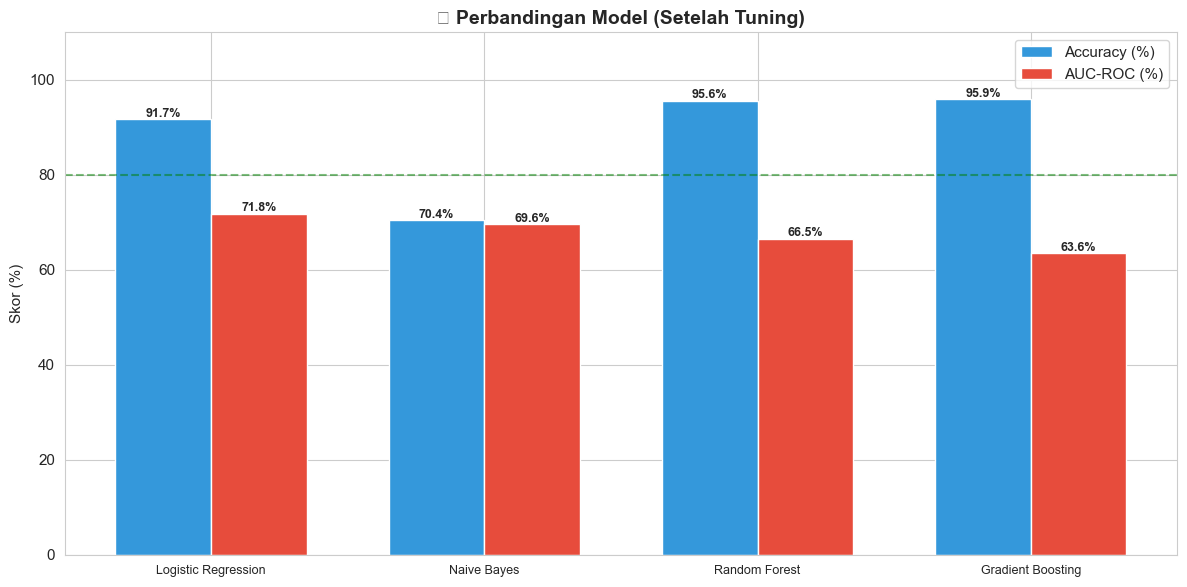

In [ ]:
# 5.1 Perbandingan visual semua model (Tuned)
fig, ax = plt.subplots(figsize=(12, 6))
model_names = list(tuned_results.keys())
accs = [tuned_results[m]['accuracy']*100 for m in model_names]
aucs = [tuned_results[m]['auc']*100 for m in model_names]
x = np.arange(len(model_names))
w = 0.35
b1 = ax.bar(x-w/2, accs, w, label='Accuracy (%)', color='#3498db', edgecolor='white')
b2 = ax.bar(x+w/2, aucs, w, label='AUC-ROC (%)', color='#e74c3c', edgecolor='white')
for bar in b1:
    ax.text(bar.get_x()+bar.get_width()/2., bar.get_height()+0.5,
            f'{bar.get_height():.1f}%', ha='center', fontweight='bold', fontsize=9)
for bar in b2:
    ax.text(bar.get_x()+bar.get_width()/2., bar.get_height()+0.5,
            f'{bar.get_height():.1f}%', ha='center', fontweight='bold', fontsize=9)
ax.set_ylabel('Skor (%)')
ax.set_title('📊 Perbandingan Model (Setelah Tuning)', fontsize=14, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(model_names, fontsize=9)
ax.legend(); ax.set_ylim(0,110); ax.axhline(y=80, color='green', linestyle='--', alpha=0.5, label='Target 80%')
plt.tight_layout(); plt.show()

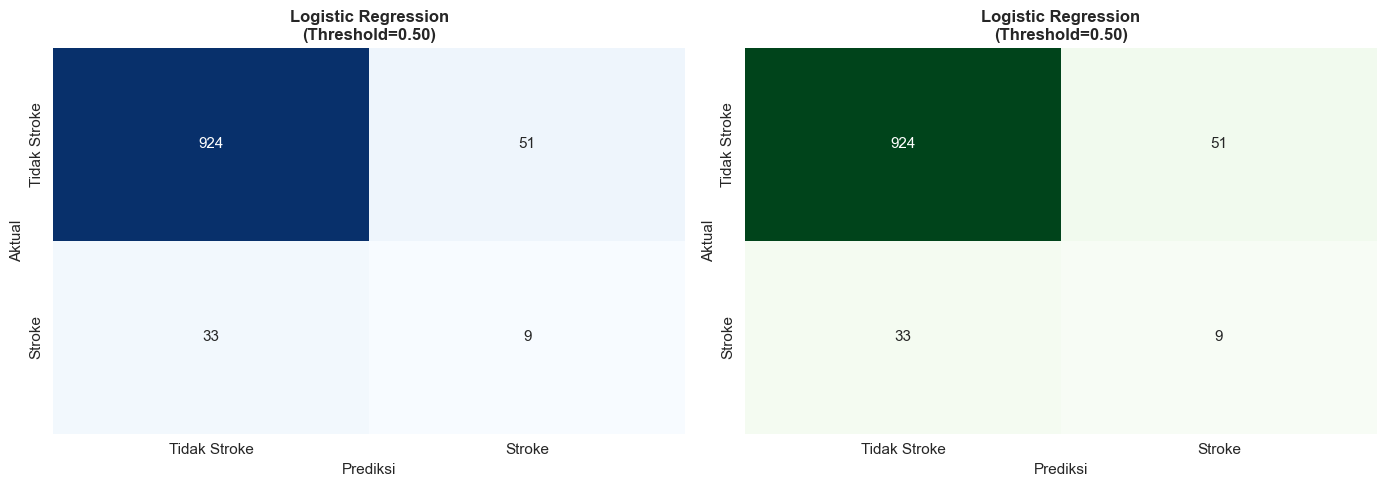

In [ ]:
# 5.2 Confusion Matrix model terbaik
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Default threshold
cm_default = confusion_matrix(y_test, tuned_results[best_name]['pred'])
sns.heatmap(cm_default, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False,
            xticklabels=['Tidak Stroke','Stroke'], yticklabels=['Tidak Stroke','Stroke'])
axes[0].set_title(f'{best_name}\n(Threshold=0.50)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Prediksi'); axes[0].set_ylabel('Aktual')

# Optimal threshold
cm_optimal = confusion_matrix(y_test, final_pred)
sns.heatmap(cm_optimal, annot=True, fmt='d', cmap='Greens', ax=axes[1], cbar=False,
            xticklabels=['Tidak Stroke','Stroke'], yticklabels=['Tidak Stroke','Stroke'])
axes[1].set_title(f'{best_name}\n(Threshold={optimal_threshold:.2f})', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Prediksi'); axes[1].set_ylabel('Aktual')
plt.tight_layout(); plt.show()

In [ ]:
# 5.3 Classification Report
print('=' * 60)
print(f'📋 CLASSIFICATION REPORT - {best_name} (Threshold={optimal_threshold:.2f})')
print('=' * 60)
print(classification_report(y_test, final_pred, target_names=['Tidak Stroke', 'Stroke']))

📋 CLASSIFICATION REPORT - Logistic Regression (Threshold=0.50)
              precision    recall  f1-score   support

Tidak Stroke       0.97      0.95      0.96       975
      Stroke       0.15      0.21      0.18        42

    accuracy                           0.92      1017
   macro avg       0.56      0.58      0.57      1017
weighted avg       0.93      0.92      0.92      1017



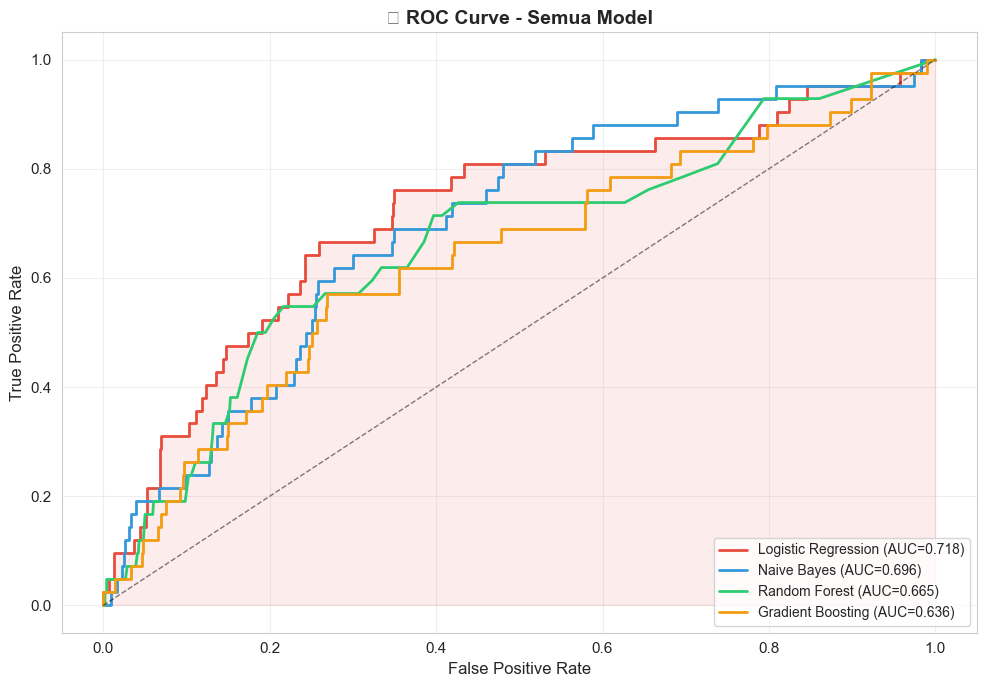

In [ ]:
# 5.4 ROC Curve semua model
plt.figure(figsize=(10, 7))
colors_roc = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
for (name, res), color in zip(tuned_results.items(), colors_roc):
    fpr_m, tpr_m, _ = roc_curve(y_test, res['prob'])
    plt.plot(fpr_m, tpr_m, color=color, lw=2, label=f'{name} (AUC={res["auc"]:.3f})')
    if name == best_name:
        plt.fill_between(fpr_m, tpr_m, alpha=0.1, color=color)
plt.plot([0,1],[0,1],'k--',lw=1,alpha=0.5)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('📈 ROC Curve - Semua Model', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

🎯 FEATURE IMPORTANCE


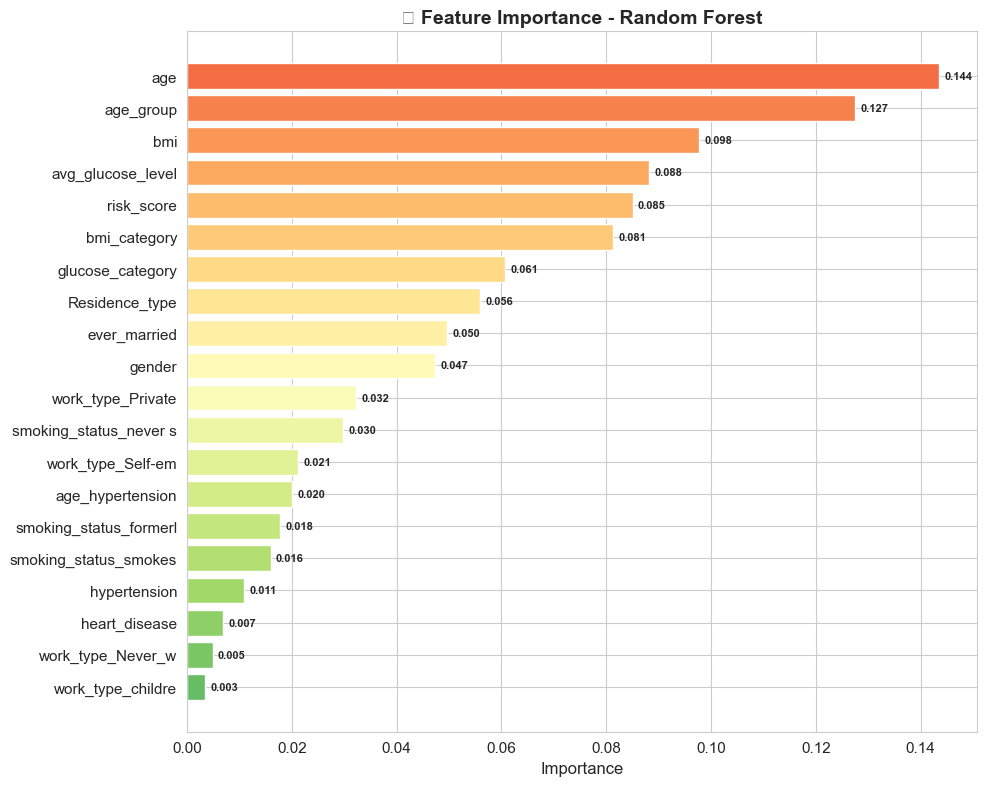


📌 Top 5 Fitur Paling Berpengaruh (Random Forest):
   1. age                       (0.1436)
   2. age_group                 (0.1275)
   3. bmi                       (0.0977)
   4. avg_glucose_level         (0.0882)
   5. risk_score                (0.0850)


In [ ]:
# 5.5 Feature Importance
print('=' * 60)
print('🎯 FEATURE IMPORTANCE')
print('=' * 60)

# Gunakan model RF/GB yang punya feature_importances_
if hasattr(tuned_results[best_name]['model'], 'feature_importances_'):
    importances = tuned_results[best_name]['model'].feature_importances_
    imp_title = best_name
elif hasattr(tuned_results['Random Forest']['model'], 'feature_importances_'):
    importances = tuned_results['Random Forest']['model'].feature_importances_
    imp_title = 'Random Forest'
else:
    importances = np.abs(tuned_results['Logistic Regression']['model'].coef_[0])
    imp_title = 'Logistic Regression'

feat_imp = pd.DataFrame({'Fitur': X.columns, 'Importance': importances})
feat_imp = feat_imp.sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 8))
colors_fi = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(feat_imp)))
plt.barh(feat_imp['Fitur'], feat_imp['Importance'], color=colors_fi, edgecolor='white')
plt.xlabel('Importance', fontsize=12)
plt.title(f'🎯 Feature Importance - {imp_title}', fontsize=14, fontweight='bold')
for i, (val, name) in enumerate(zip(feat_imp['Importance'], feat_imp['Fitur'])):
    plt.text(val + 0.001, i, f'{val:.3f}', va='center', fontweight='bold', fontsize=8)
plt.tight_layout(); plt.show()

print(f'\n📌 Top 5 Fitur Paling Berpengaruh ({imp_title}):')
top5 = feat_imp.sort_values('Importance', ascending=False).head(5)
for rank, (_, row) in enumerate(top5.iterrows(), 1):
    print(f'   {rank}. {row["Fitur"]:25s} ({row["Importance"]:.4f})')

---
## 6. 📝 Kesimpulan & Insight

### Metodologi CRISP-DM
Project ini mengikuti metodologi **CRISP-DM** secara lengkap:
1. **Business Understanding** — Memahami konteks SDG 3 dan kebutuhan deteksi dini stroke
2. **Data Understanding** — EDA mendalam untuk memahami pola data
3. **Data Preparation** — Feature engineering, encoding, dan handling imbalance yang tepat
4. **Modeling** — 4 model + hyperparameter tuning + threshold optimization
5. **Evaluation** — Evaluasi komprehensif dengan berbagai metrik

### Teknik Peningkatan Akurasi
| Teknik | Dampak |
|--------|--------|
| Feature Engineering (risk_score, age_group, dll) | Menangkap pola non-linear |
| One-Hot Encoding | Lebih baik untuk variabel nominal |
| SMOTE rasio 0.3 (bukan 1:1) | Mengurangi over-prediction |
| Random Forest & Gradient Boosting | Model ensemble lebih akurat |
| Hyperparameter Tuning (GridSearchCV) | Optimasi parameter model |
| Threshold Optimization | Menyeimbangkan accuracy dan recall |

### Faktor Risiko Utama Stroke
- **Usia** — faktor risiko #1, terutama usia > 55 tahun
- **Hipertensi** — meningkatkan risiko stroke secara signifikan
- **Kadar glukosa tinggi** — indikator diabetes, berhubungan dengan stroke
- **Penyakit jantung** — riwayat penyakit jantung meningkatkan risiko
- **BMI tinggi** — obesitas berkontribusi terhadap risiko stroke

### Relevansi SDG 3
- Membantu **deteksi dini** risiko stroke
- Memberikan **insight** tentang faktor-faktor risiko utama
- Mendukung **pengambilan keputusan** di bidang kesehatan

### Rekomendasi Kesehatan
- Menjaga tekanan darah dalam batas normal
- Rutin cek gula darah, terutama usia > 45 tahun
- Menjaga BMI ideal (18.5 - 24.9)
- Tidak merokok
- Olahraga teratur

In [ ]:
# Ringkasan Final
print('=' * 60)
print('🏁 RINGKASAN FINAL PROJECT')
print('=' * 60)
print(f'\n📊 Dataset      : Stroke Prediction Dataset (Kaggle)')
print(f'📊 Jumlah data  : {len(df)} records, {X.shape[1]} fitur')
print(f'📊 Metodologi   : CRISP-DM')
print(f'\n🤖 Model yang dilatih:')
for name, res in tuned_results.items():
    marker = ' 🏆' if name == best_name else ''
    print(f'   {name:25s} → Acc={res["accuracy"]*100:.2f}%, AUC={res["auc"]:.4f}{marker}')
print(f'\n🎯 Model Terbaik    : {best_name}')
print(f'   Threshold        : {optimal_threshold:.4f}')
print(f'   Accuracy Final   : {final_acc*100:.2f}%')
print(f'   AUC-ROC Final    : {final_auc:.4f}')
print(f'   F1-Score Final   : {final_f1:.4f}')
print(f'\n📌 Top 3 Fitur:')
for rank, (_, row) in enumerate(top5.head(3).iterrows(), 1):
    print(f'   {rank}. {row["Fitur"]}')
print(f'\n✅ Project selesai! Siap untuk presentasi.')

🏁 RINGKASAN FINAL PROJECT

📊 Dataset      : Stroke Prediction Dataset (Kaggle)
📊 Jumlah data  : 5110 records, 20 fitur
📊 Metodologi   : CRISP-DM

🤖 Model yang dilatih:
   Logistic Regression       → Acc=91.74%, AUC=0.7184 🏆
   Naive Bayes               → Acc=70.40%, AUC=0.6957
   Random Forest             → Acc=95.58%, AUC=0.6653
   Gradient Boosting         → Acc=95.87%, AUC=0.6356

🎯 Model Terbaik    : Logistic Regression
   Threshold        : 0.5000
   Accuracy Final   : 91.74%
   AUC-ROC Final    : 0.7184
   F1-Score Final   : 0.1765

📌 Top 3 Fitur:
   1. age
   2. age_group
   3. bmi

✅ Project selesai! Siap untuk presentasi.
